In [1]:
import pandas as pd

In [3]:
import zipfile
with zipfile.ZipFile('/content/data.zip', 'r') as z:
    with z.open('CUADv1.json') as f:
        df = pd.read_json(f)

In [5]:
df.head()

,version,data
0,aok_v1.0,{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...
1,aok_v1.0,"{'title': 'WHITESMOKE,INC_11_08_2011-EX-10.26-..."
2,aok_v1.0,{'title': 'LohaCompanyltd_20191209_F-1_EX-10.1...
3,aok_v1.0,{'title': 'CENTRACKINTERNATIONALINC_10_29_1999...
4,aok_v1.0,{'title': 'NELNETINC_04_08_2020-EX-1-JOINT FIL...


In [10]:
 df.dropna()

,version,data
0,aok_v1.0,{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...
1,aok_v1.0,"{'title': 'WHITESMOKE,INC_11_08_2011-EX-10.26-..."
2,aok_v1.0,{'title': 'LohaCompanyltd_20191209_F-1_EX-10.1...
3,aok_v1.0,{'title': 'CENTRACKINTERNATIONALINC_10_29_1999...
4,aok_v1.0,{'title': 'NELNETINC_04_08_2020-EX-1-JOINT FIL...
...,...,...
505,aok_v1.0,{'title': 'XinhuaSportsEntertainmentLtd_200702...
506,aok_v1.0,{'title': 'MERITLIFEINSURANCECO_06_19_2020-EX-...
507,aok_v1.0,"{'title': 'TALLGRASSENERGY,LP_02_20_2020-EX-99..."
508,aok_v1.0,{'title': 'KINGPHARMACEUTICALSINC_08_09_2006-E...


In [11]:
df.isnull().sum()

,0
version,0
data,0


In [9]:
df.shape

(510, 2)

In [12]:
# Remove entries with no text content
data_df_clean = data_df[data_df['contract_length'] > 0].copy()

# Clean up titles by stripping whitespace
data_df_clean['title'] = data_df_clean['title'].str.strip()

print(f"Original shape: {data_df.shape}")
print(f"Cleaned shape: {data_df_clean.shape}")
data_df_clean.head()

Original shape: (510, 4)
Cleaned shape: (510, 4)


,title,paragraphs,clause_count,contract_length
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,[{'qas': [{'answers': [{'text': 'DISTRIBUTOR A...,1,54290
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",[{'qas': [{'answers': [{'text': 'Promotion and...,1,70383
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,[{'qas': [{'answers': [{'text': 'SUPPLY CONTRA...,1,11475
3,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,[{'qas': [{'answers': [{'text': 'WEB SITE HOST...,1,15176
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,[{'qas': [{'answers': [{'text': 'JOINT FILING ...,1,1081


In [13]:
# Calculate descriptive statistics for contract_length
stats = data_df_clean['contract_length'].describe()
display(stats)

,contract_length
count,510.000000
mean,52563.005882
std,55946.484865
min,645.000000
25%,16416.250000
50%,33143.000000
75%,66394.750000
max,338211.000000


In [14]:
# Identify outliers using the IQR method
Q1 = data_df_clean['contract_length'].quantile(0.25)
Q3 = data_df_clean['contract_length'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = data_df_clean[data_df_clean['contract_length'] > upper_bound].sort_values(by='contract_length', ascending=False)

print(f"Upper bound for outliers: {upper_bound:.2f} characters")
print(f"Number of potential outliers found: {len(outliers)}")
display(outliers[['title', 'contract_length']].head(10))

Upper bound for outliers: 141362.50 characters
Number of potential outliers found: 45


,title,contract_length
443,MANUFACTURERSSERVICESLTD_06_05_2000-EX-10.14-O...,338211
187,"CERES,INC_01_25_2012-EX-10.20-Collaboration Ag...",335282
470,"GOOSEHEADINSURANCE,INC_04_02_2018-EX-10.6-Fran...",300768
177,PhasebioPharmaceuticalsInc_20200330_10-K_EX-10...,291873
53,VerizonAbsLlc_20200123_8-K_EX-10.4_11952335_EX...,289615
254,"Array BioPharma Inc. - LICENSE, DEVELOPMENT AN...",272018
258,RevolutionMedicinesInc_20200117_S-1_EX-10.1_11...,266213
128,HarpoonTherapeuticsInc_20200312_10-K_EX-10.18_...,249551
162,MRSFIELDSORIGINALCOOKIESINC_01_29_1998-EX-10-F...,249359
86,AzulSa_20170303_F-1A_EX-10.3_9943903_EX-10.3_M...,233248


In [15]:
# Identify the 10 shortest contracts
shortest_contracts = data_df_clean.sort_values(by='contract_length', ascending=True).head(10)

print("Top 10 Shortest Contracts:")
display(shortest_contracts[['title', 'contract_length']])

Top 10 Shortest Contracts:


,title,contract_length
207,RMRGROUPINC_01_22_2020-EX-99.1-JOINT FILING AG...,645
453,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,857
485,"PRECIGEN,INC_01_22_2020-EX-99.1-JOINT FILING A...",972
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,1081
66,"VIRGINGALACTICHOLDINGS,INC_04_08_2020-EX-99.1-...",1194
202,BLACKROCKMUNIHOLDINGSINVESTMENTQUALITYFUND_04_...,1283
454,"MACY_S,INC_05_11_2020-EX-99.4-JOINT FILING AGR...",1397
264,"SPRINGBANKPHARMACEUTICALS,INC_04_08_2020-EX-99...",1556
46,GALACTICOMMTECHNOLOGIESINC_11_07_1997-EX-10.46...,1660
133,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,1707


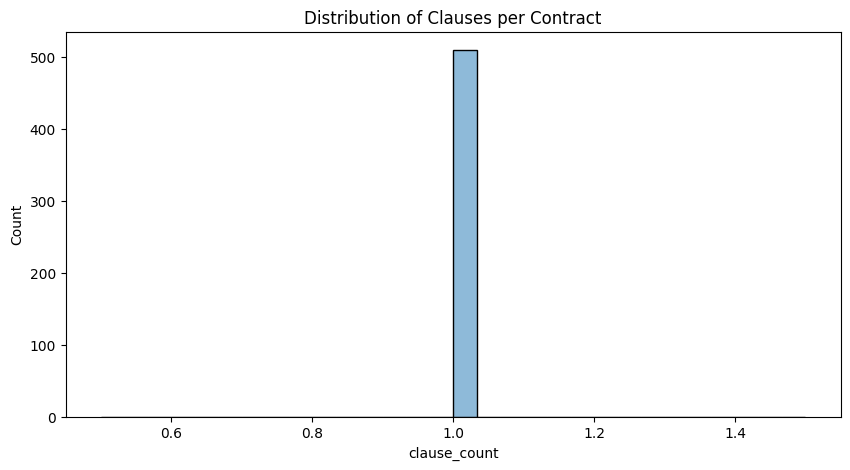

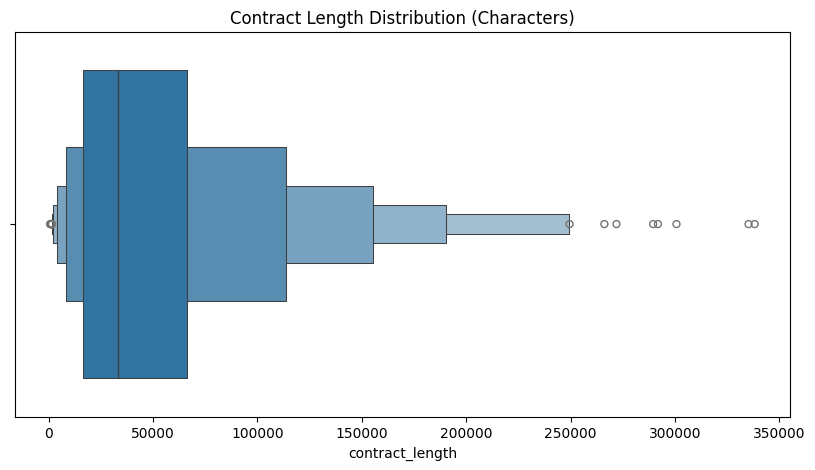

Columns available for categorization: ['title', 'paragraphs', 'clause_count', 'contract_length']


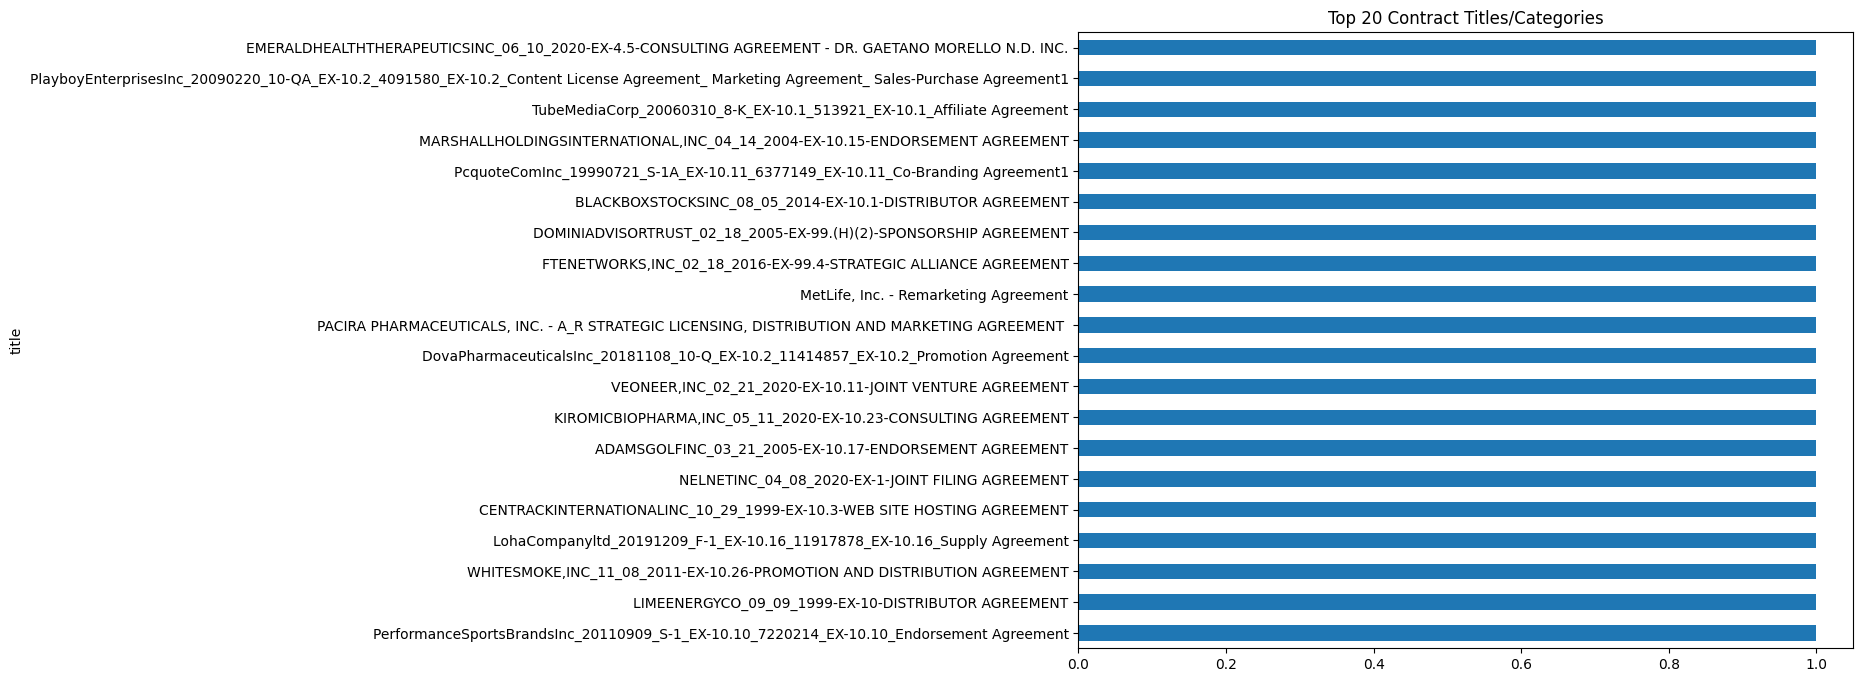

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the nested data column
data_df = pd.json_normalize(df['data'])

# 1. Clause Distribution (assuming 'paragraphs' exists in the schema)
if 'paragraphs' in data_df.columns:
    data_df['clause_count'] = data_df['paragraphs'].apply(len)
    plt.figure(figsize=(10, 5))
    sns.histplot(data_df['clause_count'], bins=30, kde=True)
    plt.title('Distribution of Clauses per Contract')
    plt.show()

# 2. Contract Lengths
# Assuming there is a text field like 'context' or the sum of paragraph lengths
def get_total_length(row):
    if 'paragraphs' in row and isinstance(row['paragraphs'], list):
        return sum(len(p.get('context', '')) for p in row['paragraphs'])
    return 0

data_df['contract_length'] = data_df.apply(get_total_length, axis=1)
plt.figure(figsize=(10, 5))
sns.boxenplot(x=data_df['contract_length'])
plt.title('Contract Length Distribution (Characters)')
plt.show()

# 3. Category Imbalance
# Checking for common keys that might represent categories or labels
print("Columns available for categorization:", data_df.columns.tolist())
# If a 'title' or specific label exists, we count it
if 'title' in data_df.columns:
    plt.figure(figsize=(10, 8))
    data_df['title'].value_counts().head(20).plot(kind='barh')
    plt.title('Top 20 Contract Titles/Categories')
    plt.show()

In [16]:
import spacy
from spacy import displacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

# Take the text from the first contract in the dataset for demonstration
# We'll extract the first 2000 characters to keep the visualization manageable
sample_contract_text = data_df_clean.iloc[0]['paragraphs'][0].get('context', '')[:2000]

# Process the text
doc = nlp(sample_contract_text)

# Display entities found
print(f"Entities found in: {data_df_clean.iloc[0]['title']}\n")
for ent in doc.ents:
    print(f"{ent.text} ({ent.label_})")

# Visualize with displacy
display(displacy.render(doc, style='ent', jupyter=True))

Entities found in: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT

10.6

                               (CARDINAL)
DISTRIBUTOR AGREEMENT

          (ORG)
DISTRIBUTOR  AGREEMENT (ORG)
Electric City Corp. (ORG)
Delaware (GPE)
Electric City (GPE)
Distributor (WORK_OF_ART)
this 7th day of September, 1999 (DATE)
Company (ORG)
Energy  Saver (WORK_OF_ART)
Company (ORG)
Company (ORG)
Agreement (PRODUCT)
Distributor (PERSON)
Objectives (ORG)
Distributor (ORG)
Company (ORG)
the State of  Illinois (ORG)
Distributor (LOC)


None

In [17]:
%%capture
!pip install transformers datasets accelerate

### Initialize Legal-BERT
We will use the `nlpaueb/legal-bert-base-uncased` model which is pre-trained on a large corpus of legal documents (including UK, US, and EU legislation and cases).

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# For demonstration, we'll initialize for sequence classification with 2 labels
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

print(f"Loaded {model_name} successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/222k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

Loaded nlpaueb/legal-bert-base-uncased successfully.


### Prepare Data for Fine-Tuning
To fine-tune, we need to tokenize the contract text. Below is a helper function to process a sample of our cleaned dataset.

In [19]:
def tokenize_function(text):
    return tokenizer(text, padding="max_length", truncation=True, max_length=512)

# Example: Tokenize the first 5 contract contexts
sample_texts = [p[0].get('context', '') for p in data_df_clean['paragraphs'].head(5)]
tokenized_inputs = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

print("Tokenized input shape:", tokenized_inputs['input_ids'].shape)

Tokenized input shape: torch.Size([5, 512])


In [20]:
%%capture
!pip install sentence-transformers faiss-cpu

### Build FAISS Semantic Search
We will use a pre-trained Sentence-Transformer model to convert our contract text into dense vectors and then use FAISS (Facebook AI Similarity Search) to index these vectors for fast retrieval.

In [21]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Load a pre-trained model suitable for semantic search
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Prepare text for embedding (using the first paragraph/context of each contract)
# In a production setting, you might chunk long documents
texts = [p[0].get('context', '')[:1000] for p in data_df_clean['paragraphs']]

# Generate embeddings
embeddings = embedder.encode(texts, show_progress_bar=True)

# Initialize FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

print(f"Indexed {index.ntotal} contract segments into FAISS.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Indexed 510 contract segments into FAISS.


### Test Semantic Search
You can now query the dataset using natural language. The system will find the most semantically similar contract segments.

In [22]:
def semantic_search(query, k=3):
    query_vector = embedder.encode([query])
    distances, indices = index.search(query_vector.astype('float32'), k)

    print(f"Results for query: '{query}'\n")
    for i, idx in enumerate(indices[0]):
        title = data_df_clean.iloc[idx]['title']
        score = distances[0][i]
        print(f"{i+1}. {title} (Distance: {score:.4f})")

# Example query
semantic_search("agreements related to renewable energy or electricity")

Results for query: 'agreements related to renewable energy or electricity'

1. SPIENERGYCO,LTD_07_10_2014-EX-10-Cooperation Agreement of 50MWp Photovoltaic Grid-connected Power Generation Project in Yangqiao of~1 (Distance: 0.8207)
2. FuelcellEnergyInc_20191106_8-K_EX-10.1_11868007_EX-10.1_Development Agreement (Distance: 0.9352)
3. ORBSATCORP_08_17_2007-EX-7.3-STRATEGIC ALLIANCE AGREEMENT (Distance: 1.0049)


### Build Legal RAG Assistant
We will combine the FAISS retriever with Gemini to generate responses based on the retrieved legal context.

In [26]:
from transformers import pipeline

# Using a local Hugging Face model for generation as a reliable alternative
try:
    generator = pipeline('text-generation', model='gpt2')
    print('Local generator model (GPT-2) loaded successfully.')
except Exception as e:
    print(f'Error loading generator: {e}')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Local generator model (GPT-2) loaded successfully.


In [27]:
def legal_rag_assistant(query, k=2):
    # 1. Retrieval using the existing FAISS index
    query_vector = embedder.encode([query])
    distances, indices = index.search(query_vector.astype('float32'), k)

    retrieved_contexts = []
    for idx in indices[0]:
        context = data_df_clean.iloc[idx]['paragraphs'][0].get('context', '')[:500]
        title = data_df_clean.iloc[idx]['title']
        retrieved_contexts.append(f'Source: {title} Context: {context}')

    full_context = ' '.join(retrieved_contexts)

    # 2. Generation using local fallback
    prompt = f'Context: {full_context}\nQuestion: {query}\nAnswer:'

    result = generator(prompt, max_new_tokens=50, num_return_sequences=1, truncation=True)
    return result[0]['generated_text'].split('Answer:')[-1].strip()

In [28]:
# Test the RAG Assistant again with the local fallback
user_query = 'What are the responsibilities of a distributor?'
print(f'Query: {user_query}\n')
try:
    answer = legal_rag_assistant(user_query)
    print('Assistant Response:\n')
    print(answer)
except Exception as e:
    print(f'RAG Error: {e}')

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: What are the responsibilities of a distributor?

Assistant Response:

To provide the pre-disclosure information and to provide a notice of the pre-disclosure pursuant to the terms of the AGREEMENT. At the same time, all of the following may be taken into account during the pre-disclosure:


### Deployment Preparation: FastAPI Application
To deploy this on AWS (e.g., via App Runner, Lambda, or EC2), we need to wrap the logic in a web framework like FastAPI. Below, we create a script that defines the API.

In [29]:
%%writefile legal_app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
# We'll assume the environment has the model and index loaded in a real deployment script
# For this demo, we'll define the structure

app = FastAPI(title="Legal Contract RAG API")

class QueryRequest(BaseModel):
    question: str
    k: int = 2

class QueryResponse(BaseModel):
    question: str
    answer: str

@app.get("/")
def read_root():
    return {"message": "Legal RAG Assistant API is online"}

@app.post("/query", response_model=QueryResponse)
def ask_legal_assistant(request: QueryRequest):
    try:
        # This would call the legal_rag_assistant function we defined earlier
        # In a real AWS deployment, you'd load the FAISS index and model at startup
        return {
            "question": request.question,
            "answer": "This is a placeholder. In production, the model would process: " + request.question
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Writing legal_app.py
